# CNM Analysis: RHIC d+Au 200 GeV

Step-by-step decomposition of CNM effects using EPPS21 nPDF and Arleo-Peigné energy loss for d+Au collisions.

## 1. Setup & Imports

In [1]:
import sys, os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add repo paths
HERE = Path(".").resolve()
sys.path.append(str(HERE.parent / "eloss_code"))
sys.path.append(str(HERE.parent / "npdf_code"))
sys.path.append(str(HERE.parent / "cnm_combine"))

from cnm_combine_fast import CNMCombineFast
from cnm_combine import combine_two_bands_1d, _tags_for_cent_bins
from npdf_centrality import bin_rpa_vs_y, bin_rpa_vs_pT, bin_rpa_vs_centrality, make_centrality_weight_dict

print("Environment ready.")


Environment ready.


In [2]:
import npdf_centrality_dAu as npdf_rhic
print("RHIC nPDF module loaded.")

RHIC nPDF module loaded.


In [3]:
def plot_component_decomposition(x, final_bands, labels, xlabel, title, filename=None):
    """
    Plots MinBias decomposition and Centrality-dependent total CNM.
    """
    # 1. Total CNM vs Centrality
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(labels)))
    for i, lab in enumerate(labels + ["MB"]):
        c = colors[i] if i < len(labels) else "black"
        Dc, Dlo, Dhi = final_bands["cnm"]
        if lab not in Dc: continue
        ax.plot(x, Dc[lab], color=c, label=lab, lw=2)
        ax.fill_between(x, Dlo[lab], Dhi[lab], color=c, alpha=0.15)
    
    ax.axhline(1, color='k', ls=':', alpha=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("$R_{pA}$")
    ax.set_title(f"{title} - Total CNM")
    ax.legend(title="Centrality", loc="best", ncol=2)
    if filename: fig.savefig(str(filename).replace(".png", "_Total.png"), dpi=150)

    # 2. MinBias Decomposition
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    comps = [("npdf", "nPDF", "magenta"), ("eloss", "Energy Loss", "green"), 
             ("broad", "Broadening", "orange"), ("cnm", "Total CNM", "blue")]
    for comp, name, col in comps:
        if comp in final_bands:
            Dc, Dlo, Dhi = final_bands[comp]
            if "MB" in Dc:
                ax2.plot(x, Dc["MB"], color=col, label=name, lw=2)
                ax2.fill_between(x, Dlo["MB"], Dhi["MB"], color=col, alpha=0.1)
    
    ax2.axhline(1, color='k', ls=':', alpha=0.5)
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel("$R_{pA}$ (MinBias)")
    ax2.set_title(f"{title} - Component Decomposition")
    ax2.legend()
    if filename: fig2.savefig(str(filename).replace(".png", "_Decomp.png"), dpi=150)
    return fig, fig2

def plot_centrality_sweep(res_cent, labels, title, filename=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    x_idx = np.arange(len(labels))
    for comp, name, col in [("npdf", "nPDF", "magenta"), ("eloss_broad", "Eloss*Broad", "gray"), ("cnm", "Total CNM", "blue")]:
        if comp not in res_cent: continue
        Vc, Vlo, Vhi, MBc, MBlo, MBhi = res_cent[comp]
        ax.errorbar(x_idx, Vc, yerr=[Vc-Vlo, Vhi-Vc], fmt='o-', color=col, label=name, capsize=4)
        ax.axhline(MBc, color=col, ls='--', alpha=0.3)
    
    ax.set_xticks(x_idx)
    ax.set_xticklabels(labels)
    ax.set_xlabel("Centrality Bin")
    ax.set_ylabel("$R_{pA}$")
    ax.set_title(title)
    ax.legend()
    if filename: fig.savefig(filename, dpi=150)


### 1. Initialize RHIC Pipeline

In [4]:
energy = "200"
OUTDIR = Path(f"outputs/RHIC_200GeV")
OUTDIR.mkdir(parents=True, exist_ok=True)

rhic_windows = [(-2.2, -1.2, "d-going"), (-0.35, 0.35, "Mid-rap"), (1.2, 2.2, "Au-going")]
cnm = CNMCombineFast.from_defaults(
    energy=energy, family="charmonia", particle_state="avg",
    cent_bins=[(0,20), (20,40), (40,60), (60,88)],
    y_windows=rhic_windows
)
labels = [f"{int(a)}-{int(b)}%" for (a,b) in cnm.cent_bins]
print("Ready for RHIC.")

Ready for RHIC.


### 2. $R_{dAu}$ vs Rapidity

Calculating nPDF vs y...


Calculating Eloss and Broadening vs y...


Combining results...


Done.


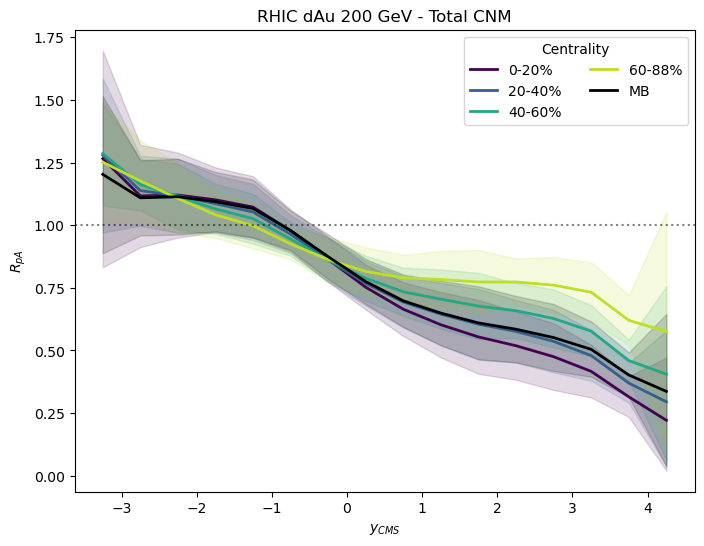

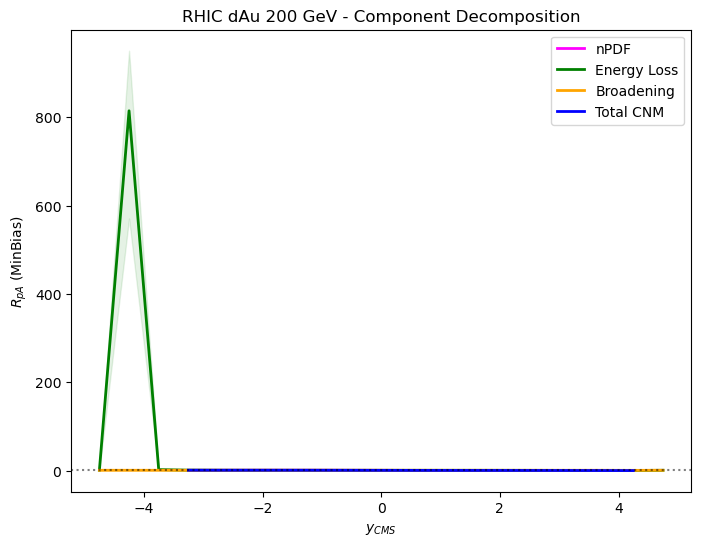

In [5]:
print("Calculating nPDF vs y...")
wcent = make_centrality_weight_dict(cnm.cent_bins, c0=cnm.cent_c0)
npdf_y = npdf_rhic.bin_rpa_vs_y(
    cnm.npdf_ctx['df49_by_cent'], cnm.npdf_ctx['df_pp'], cnm.npdf_ctx['df_pa'], cnm.npdf_ctx['gluon'],
    cent_bins=cnm.cent_bins, y_edges=cnm.y_edges, pt_range_avg=cnm.pt_range_avg, wcent_dict=wcent
)

print("Calculating Eloss and Broadening vs y...")
y_cent, e_bands_y, _ = cnm._calc_eloss_broad_band_vs_y(cnm.y_edges, cnm.pt_range_avg, ["loss","broad","eloss_broad"])

print("Combining results...")
final_y = cnm._combine_bands_generic(["npdf","eloss","broad","eloss_broad","cnm"], npdf_y, e_bands_y, labels, True, mode="y")

plot_component_decomposition(y_cent, final_y, labels, "$y_{CMS}$", "RHIC dAu 200 GeV", filename=OUTDIR/"RpA_vs_y.png")
print("Done.")

### 3. $R_{dAu}$ vs Transverse Momentum

Processing pT in window d-going...


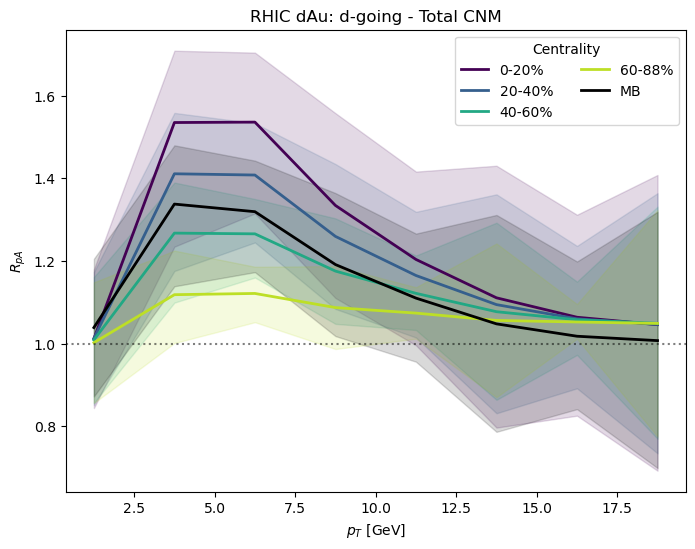

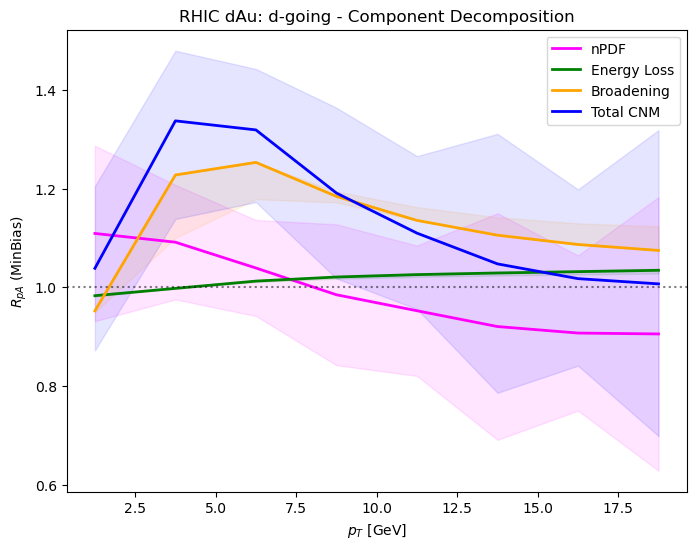

Processing pT in window Mid-rap...


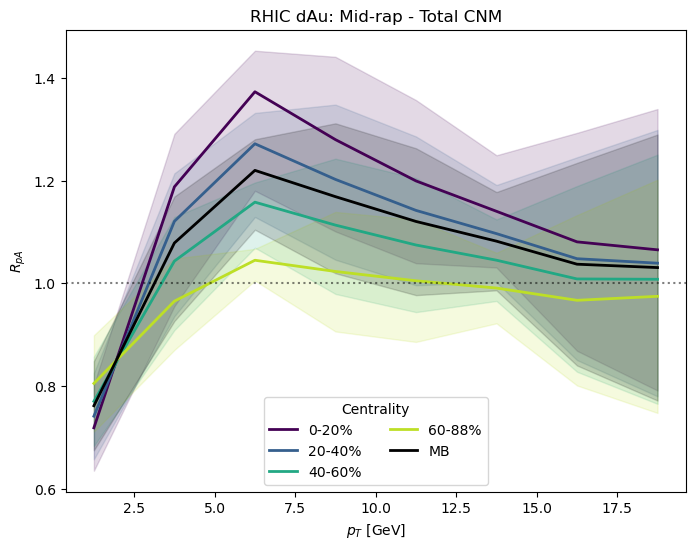

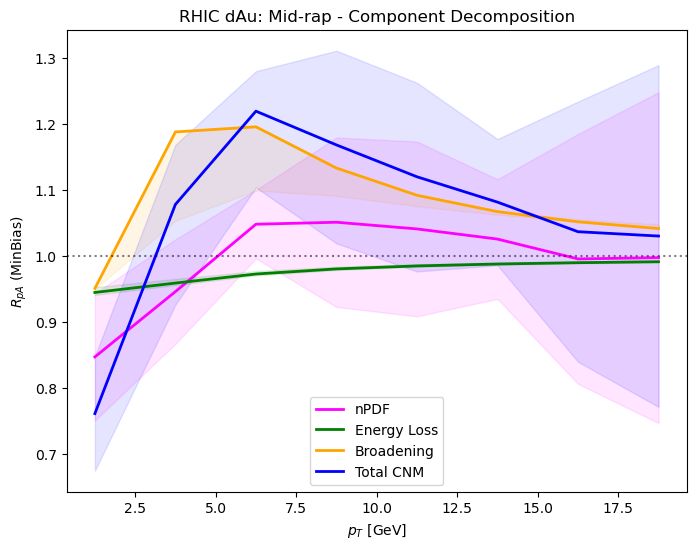

Processing pT in window Au-going...


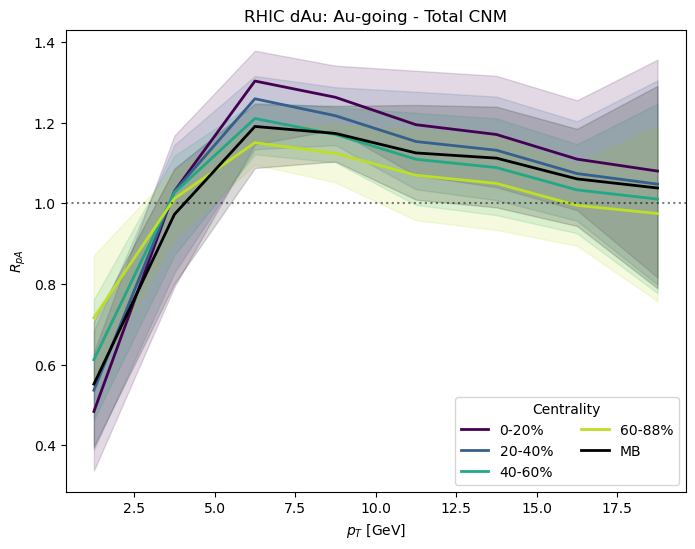

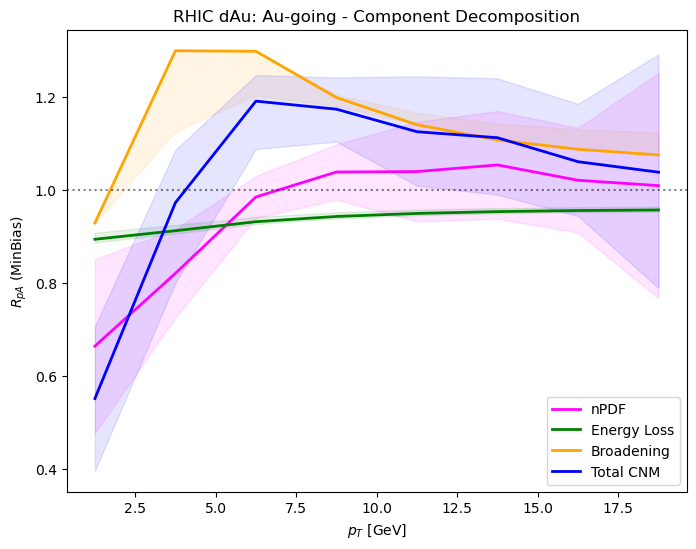

In [6]:
for (y0, y1, desc) in cnm.y_windows:
    print(f"Processing pT in window {desc}...")
    npdf_pt = npdf_rhic.bin_rpa_vs_pT(
        cnm.npdf_ctx['df49_by_cent'], cnm.npdf_ctx['df_pp'], cnm.npdf_ctx['df_pa'], cnm.npdf_ctx['gluon'],
        cent_bins=cnm.cent_bins, pt_edges=cnm.p_edges, y_window=(y0, y1), wcent_dict=wcent
)
    pt_cent, e_bands_pt, _ = cnm._calc_eloss_broad_band_vs_pT(cnm.p_edges, (y0, y1), ["loss","broad","eloss_broad"])
    final_pt = cnm._combine_bands_generic(["npdf","eloss","broad","eloss_broad","cnm"], npdf_pt, e_bands_pt, labels, True, mode="pT")
    
    plot_component_decomposition(pt_cent, final_pt, labels, "$p_T$ [GeV]", f"RHIC dAu: {desc}", filename=OUTDIR/f"RpA_vs_pT_{y0}_{y1}.png")
    plt.show()


### 4. $R_{dAu}$ vs Centrality

Processing Centrality in window d-going...


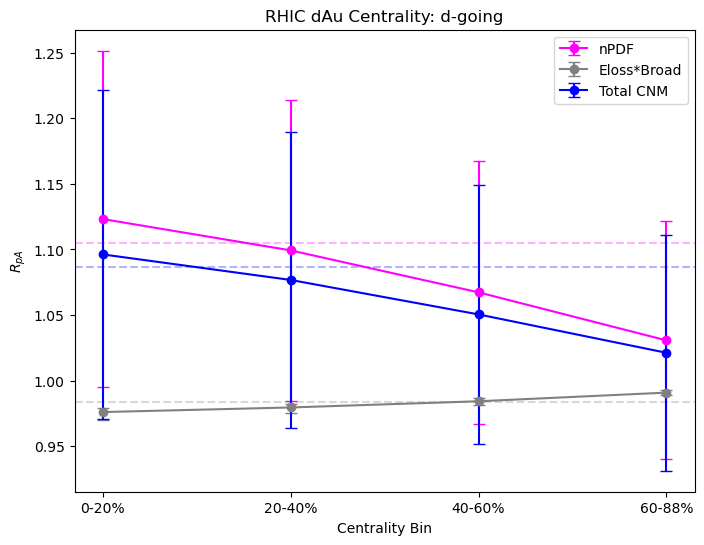

Processing Centrality in window Mid-rap...


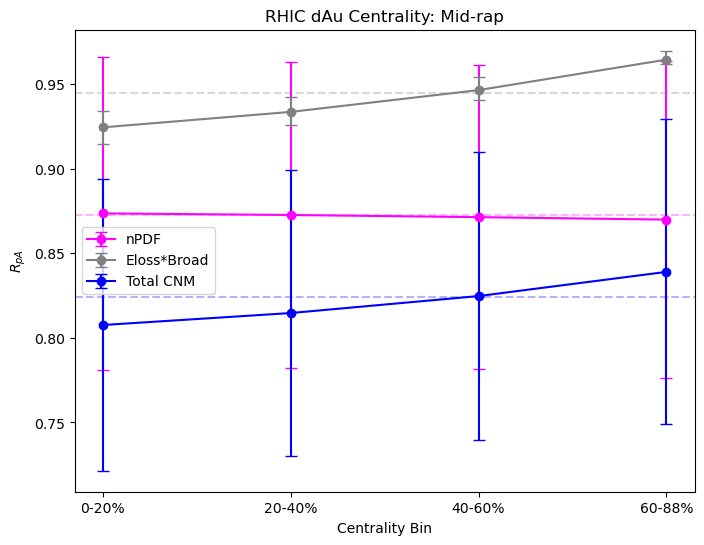

Processing Centrality in window Au-going...


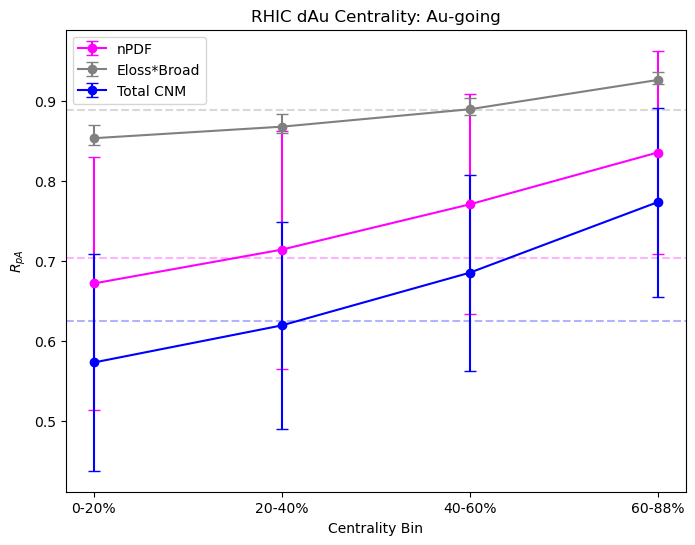

In [7]:
for (y0, y1, desc) in cnm.y_windows:
    print(f"Processing Centrality in window {desc}...")
    res_cent = cnm.cnm_vs_centrality(y_window=(y0, y1))
    plot_centrality_sweep(res_cent, labels, f"RHIC dAu Centrality: {desc}", filename=OUTDIR/f"RpA_vs_cent_{y0}_{y1}.png")
    plt.show()
